# Perceptron (TensorFlow / Keras)

The Perceptron is the simplest neural unit: it computes a weighted sum of inputs,
adds a bias, and passes the result through an activation to make a binary decision.

`output = sigmoid(w . x + b)`

We train a single-layer perceptron (a `Dense(1, activation="sigmoid")` layer) to
classify tumors as malignant/benign using the **Breast Cancer Wisconsin** dataset
(`sklearn.datasets.load_breast_cancer`), a small real-world binary classification dataset.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(0)

In [2]:
# Load real dataset: 569 samples, 30 numeric features, binary target (malignant=0, benign=1)
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape

((455, 30), (455,))

In [3]:
# A single Dense neuron with a sigmoid activation IS a perceptron
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation="sigmoid", input_shape=(X_train.shape[1],))
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(X_train, y_train, epochs=100, verbose=0)
print("final training loss:", history.history["loss"][-1])

final training loss: 0.059123143553733826


Test accuracy: 0.956


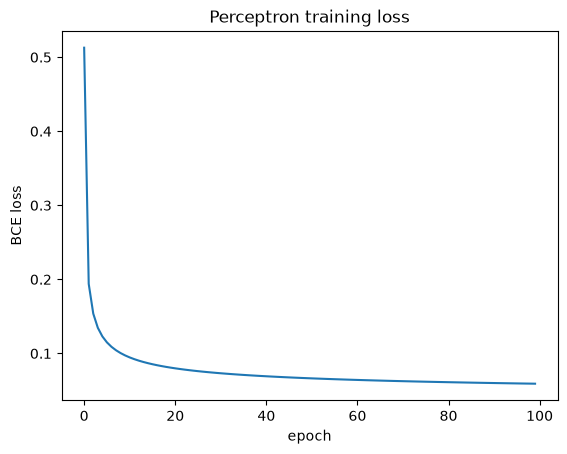

In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

plt.plot(history.history["loss"])
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Perceptron training loss")
plt.show()